In [1]:
# ═══════════════════════════════════════════════════════════════
# Cell 1: Imports and Setup
# ═══════════════════════════════════════════════════════════════
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import numpy as np
import pandas as pd

from src.models.hybrid_model import HybridChagasModel
from src.training.dataset import create_dataloaders
from src.training.trainer import ChagasTrainer

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'Memory: {mem_gb:.2f} GB')
    if mem_gb >= 12:
        print('✓ 12GB+ GPU — you can increase BATCH_SIZE to 32 in Cell 2')
    elif mem_gb < 8:
        print('⚠️  GPU < 8GB — keep BATCH_SIZE=16 + GRAD_ACCUM=4')
else:
    print('⚠️  WARNING: No GPU. Training will be extremely slow.')

print('\n✓ Imports OK')

✓ Official PhysioNet helper_code loaded from:
  D:\IIT\L6\FYP\ChagaSight\external\official_2025\helper_code.py
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Memory: 6.44 GB
⚠️  GPU < 8GB — keep BATCH_SIZE=16 + GRAD_ACCUM=4

✓ Imports OK


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Cell 2: Configuration
# ═══════════════════════════════════════════════════════════════

# ─── QUICK TEST MODE ─────────────────────────────────────────────
# Set True to run a 5-minute smoke-test before committing to full training.
# Reduces all iterations, val subset, permutations to tiny values.
# Expected output: loss should decrease, no crashes. Score will be random (~0.05).
QUICK_TEST = False  # ← Set to True for a 5-min smoke-test before full training

# ─── FOLD ────────────────────────────────────────────────────────
FOLD = 1  # Change to 1, 2, 3, 4 for other folds

# ─── PATHS ───────────────────────────────────────────────────────
DATA_DIR     = project_root / 'data' / 'processed'
METADATA_CSV = DATA_DIR / 'metadata' / 'combined_5fold.csv'
IMAGES_DIR   = DATA_DIR / '2d_images'
SIGNALS_DIR  = DATA_DIR / '1d_signals_100hz'

if not METADATA_CSV.exists():
    raise FileNotFoundError(
        f'Metadata CSV not found: {METADATA_CSV}\n'
        f'Run: python scripts/build_all_data.py && python scripts/create_splits.py'
    )
print(f'✓ Metadata CSV: {METADATA_CSV}')

CHECKPOINT_DIR = project_root / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

MAE_CHECKPOINT   = CHECKPOINT_DIR / 'mae_2d_pretrained.pt'
STMEM_CHECKPOINT = CHECKPOINT_DIR / 'stmem_1d_pretrained.pt'

# ─── HARDWARE ────────────────────────────────────────────────────
# BATCH_SIZE=16 fits a 6GB GPU.
# If you have 12GB+, use BATCH_SIZE=32 and GRAD_ACCUM=2 for same effective batch.
BATCH_SIZE  = 16
GRAD_ACCUM  = 4   # Phase 1 only. Phase 2 uses accum=1 (faster with all 173M params)
NUM_WORKERS = 4
USE_AMP     = True

# ─── TRAINING SCHEDULE (from paper: Van Santvliet et al. 2025) ───
# Phase 1: Foundation Model (1D-ViT) FROZEN → only train 2D-ViT + classifier
# Phase 2: Foundation Model UNFROZEN → fine-tune everything with differential LR
PHASE1_ITERATIONS = 2000   # ~35 min on RTX 3050
PHASE2_ITERATIONS = 12000  # ~8-10 hours on RTX 3050

PHASE1_LR      = 2e-4  # LR for classifier + 2D-ViT when FM is frozen
PHASE2_LR_HIGH = 2e-4  # LR for classifier + REPA head in Phase 2
PHASE2_LR_LOW  = 2e-5  # LR for FM + 2D-ViT in Phase 2 (10x lower = discriminative tuning)

# ─── STABILITY PARAMS ────────────────────────────────────────────
# MAX_GRAD_NORM: standard transformer gradient clip. Prevents loss=inf at random init.
# WARMUP_ITERS: linearly ramp LR from 0 → target over first 200 steps.
#               Without this, large random-init gradients can corrupt FM weights early.
MAX_GRAD_NORM = 1.0
WARMUP_ITERS  = 200

# ─── VALIDATION FREQUENCY ────────────────────────────────────────
# Phase 1: validate every 1000 iters (2 checks at iter 1000, 2000)
# Phase 2: validate every 4000 iters (3 checks at iter 4000, 8000, 12000)
# Fewer Phase 2 checkpoints = less disk-write overhead (~4 min saved per skipped save).
VAL_EVERY_P1 = 1000    # Phase 1: every 1000 iterations (2 checks total)
VAL_EVERY_P2 = 4000    # Phase 2: every 4000 iterations (3 checks total)

# ─── AUTO-RESUME ─────────────────────────────────────────────────
# Automatically resumes from the latest checkpoint if it exists.
# If the latest checkpoint is Phase 1 complete, it will skip to Phase 2.
# If the latest checkpoint is mid-Phase 2, it will continue from that iteration.
_latest_ckpt = CHECKPOINT_DIR / f'fold{FOLD}_latest.pt'
RESUME_FROM = str(_latest_ckpt) if _latest_ckpt.exists() else None

# ─── QUICK TEST OVERRIDES ─────────────────────────────────────────
if QUICK_TEST:
    print('\n⚡ QUICK_TEST MODE ACTIVE — All values scaled down for 5-min smoke-test')
    PHASE1_ITERATIONS = 25 # 50
    PHASE2_ITERATIONS = 50 #100
    WARMUP_ITERS      = 10
    VAL_EVERY_P1      = 25   # 50/25 = 2 checks in Phase 1 (iter 25, 50)
    VAL_EVERY_P2      = 50   # 100/50 = 2 checks in Phase 2 (iter 50, 100)
    NUM_WORKERS       = 4    # Easier debugging
    RESUME_FROM       = None # Always start fresh for test
    print('  Phase 1: 50 iters (2 val checks) | Phase 2: 100 iters (2 val checks) | No resume')

print(f'\n✓ Config — Fold {FOLD}:')
print(f'  QUICK_TEST:       {QUICK_TEST}')
print(f'  Batch size:       {BATCH_SIZE}')
print(f'  Grad accum P1:    {GRAD_ACCUM}  → eff.batch = {BATCH_SIZE*GRAD_ACCUM}')
print(f'  Grad accum P2:    1  → eff.batch = {BATCH_SIZE}')
print(f'  Max grad norm:    {MAX_GRAD_NORM}')
print(f'  Warmup iters:     {WARMUP_ITERS}')
print(f'  Phase 1:          {PHASE1_ITERATIONS} iters (val every {VAL_EVERY_P1})')
print(f'  Phase 2:          {PHASE2_ITERATIONS} iters (val every {VAL_EVERY_P2})')
print(f'  Auto-resume from: {RESUME_FROM or "None (fresh start)"}')

✓ Metadata CSV: d:\IIT\L6\FYP\ChagaSight\data\processed\metadata\combined_5fold.csv

✓ Config — Fold 0:
  QUICK_TEST:       False
  Batch size:       16
  Grad accum P1:    4  → eff.batch = 64
  Grad accum P2:    1  → eff.batch = 16
  Max grad norm:    1.0
  Warmup iters:     200
  Phase 1:          2000 iters (val every 1000)
  Phase 2:          12000 iters (val every 4000)
  Auto-resume from: None (fresh start)


In [3]:
# ═══════════════════════════════════════════════════════════════
# Cell 3: Create Dataloaders
# ═══════════════════════════════════════════════════════════════
# Augmentations ACTIVE for training, DISABLED for validation.
# Active augmentations (see augmentations.py DEFAULT_AUGMENTATION_CONFIG):
#   - Lead mixup (30%): blends adjacent leads V1↔V2, V5↔V6
#   - Powerline noise (30%): adds 60Hz noise per lead independently
#   - Random shift (50%): shifts signal ±100 samples (~1 second)
#   - Amplitude scaling (30%): multiplies signal by 0.8x–1.2x
#   - Baseline wander (20%): adds slow 0.1-0.5Hz drift
# Soft labels are ON for CODE-15 (0.8 pos / 0.2 neg).
# Weighted sampling: positives oversampled 5×.
print('Creating dataloaders...')

train_loader, val_loader = create_dataloaders(
    metadata_csv=str(METADATA_CSV),
    images_dir=str(IMAGES_DIR),
    signals_dir=str(SIGNALS_DIR),
    fold=FOLD,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    use_weighted_sampling=True,   # 5× oversample positives
    augment_train=True            # All augmentations above are active
)

print('\nTesting first batch...')
batch = next(iter(train_loader))
print(f'  image:       {batch["image"].shape}')    # (16, 3, 24, 2048)
print(f'  signal:      {batch["signal"].shape}')   # (16, 12, 1000)
print(f'  age:         {batch["age"].shape}')      # (16,)
print(f'  sex:         {batch["sex"].shape}')      # (16,)
print(f'  label:       {batch["label"].shape}')    # (16,)  — may include 0.8/0.2 for CODE-15
print(f'  hard_label:  {batch["hard_label"].shape}')  # (16,)  — always 0 or 1

# Verify soft labels are present for CODE-15 if applicable
unique_labels = batch['label'].unique().tolist()
print(f'\n  Unique label values in this batch: {[round(v,2) for v in unique_labels]}')
print(f'  (Expected: 0.0, 0.2, 0.8, or 1.0 depending on dataset mix)')

assert batch['label'].min() >= 0 and batch['label'].max() <= 1, 'Labels out of [0,1]!'
assert not torch.isnan(batch['signal']).any(), 'NaN detected in signals!'
assert not torch.isnan(batch['image'].float()).any(), 'NaN detected in images!'

print('\n✓ Dataloaders ready — no NaN, labels in [0,1], soft labels active for CODE-15')

Creating dataloaders...


d:\IIT\L6\FYP\ChagaSight\src\training\dataset.py:89: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_csv)
d:\IIT\L6\FYP\ChagaSight\src\training\dataset.py:89: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_csv)


✓ Loaded train fold 0: 66504 samples
  Datasets: {'ptbxl': 17439, 'samitrop': 1305, 'code15': 47760}
  Positive: 2277, Negative: 64227
✓ Loaded val fold 0: 16626 samples
  Datasets: {'ptbxl': 4360, 'samitrop': 326, 'code15': 11940}
  Positive: 569, Negative: 16057

✓ Created dataloaders for fold 0:
  Train: 66504 samples, 4156 batches
  Val:   16626 samples, 1040 batches
  Weighted sampling: True
  Augmentation: True

Testing first batch...
  image:       torch.Size([16, 3, 24, 2048])
  signal:      torch.Size([16, 12, 1000])
  age:         torch.Size([16])
  sex:         torch.Size([16])
  label:       torch.Size([16])
  hard_label:  torch.Size([16])

  Unique label values in this batch: [0.0, 0.2, 0.8]
  (Expected: 0.0, 0.2, 0.8, or 1.0 depending on dataset mix)

✓ Dataloaders ready — no NaN, labels in [0,1], soft labels active for CODE-15


In [4]:
# ═══════════════════════════════════════════════════════════════
# Cell 4: Create Model
# ═══════════════════════════════════════════════════════════════
print('Creating model...')

model = HybridChagasModel(
    img_size=(24, 2048),
    patch_size_2d=(8, 64),
    num_leads=12,
    seq_len_1d=1000,
    patch_size_1d=50,
    embed_dim=768,
    depth=12,
    num_heads=12,
    use_aol=True,
    use_demographics=True
)

# Load pretraining weights if available
# Run MAE pretraining notebook first to generate mae_2d_pretrained.pt
if MAE_CHECKPOINT.exists():
    print(f'✓ Loading MAE 2D-ViT weights: {MAE_CHECKPOINT.name}')
    model.vit_2d.load_mae_pretrained(str(MAE_CHECKPOINT))
else:
    print('⚠️  No MAE checkpoint — 2D-ViT trains from scratch')
    print('   Expected improvement from MAE: +0.05 to +0.10 on TPR@5%')

# Run ST-MEM pretraining notebook first to generate stmem_1d_pretrained.pt
if STMEM_CHECKPOINT.exists():
    print(f'✓ Loading ST-MEM 1D-ViT FM weights: {STMEM_CHECKPOINT.name}')
    model.vit_1d_fm.load_stmem_pretrained(str(STMEM_CHECKPOINT))
else:
    print('⚠️  No ST-MEM checkpoint — 1D-ViT FM trains from scratch')
    print('   Expected improvement from ST-MEM: +0.08 to +0.12 on TPR@5%')

model = model.to(device)

# Sanity check: forward pass with no grad
with torch.no_grad():
    test_out = model(
        batch['image'].to(device),
        batch['signal'].to(device),
        batch['age'].to(device),
        batch['sex'].to(device),
    )
    assert torch.isfinite(test_out['logits']).all(), 'Non-finite logits at init!'
    assert torch.isfinite(test_out['fm_features']).all(), 'Non-finite FM features!'
    print(f'\n✓ Forward pass OK:')
    print(f'  logits:             {test_out["logits"].shape}')
    print(f'  fm_features:        {test_out["fm_features"].shape}')
    print(f'  aligned_2d_features:{test_out["aligned_2d_features"].shape}')

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✓ Model ready:')
print(f'  Total params:     {total_params:,}')
print(f'  Trainable params: {trainable_params:,}')

Creating model...
✓ Loading MAE 2D-ViT weights: mae_2d_pretrained.pt

🔄 Loading MAE weights from: d:\IIT\L6\FYP\ChagaSight\checkpoints\mae_2d_pretrained.pt
   Top-level checkpoint keys: ['patch_embed', 'cls_token', 'pos_embed', 'encoder', 'encoder_norm']
   ✓ Flattened to 150 parameter tensors
   ⚠️  Trimmed CLS token: torch.Size([1, 97, 768]) → torch.Size([1, 96, 768])

✅ MAE weights loaded successfully:
   Loaded: 149 keys (was 5, now 145+ ✓)
   Missing: 0 keys (new components)
   Unexpected: 0 keys

   ✓ Transformer layers loaded: 144 weights
   Sample keys:
     - layers.0.self_attn.in_proj_weight: torch.Size([2304, 768])
     - layers.0.self_attn.in_proj_bias: torch.Size([2304])
     - layers.0.self_attn.out_proj.weight: torch.Size([768, 768])

   Critical components: 5/5 loaded
   ✓ All critical transformer weights loaded successfully!
✓ Loading ST-MEM 1D-ViT FM weights: stmem_1d_pretrained.pt

🔄 Loading ST-MEM weights from: d:\IIT\L6\FYP\ChagaSight\checkpoints\stmem_1d_pretraine

In [5]:
# ═══════════════════════════════════════════════════════════════
# Cell 5: Create Trainer (v9 params)
# ═══════════════════════════════════════════════════════════════
# KEY CHANGES vs v6:
#   - VAL_EVERY_P1=1000 → Phase 1: 2 checks (iter 1000, 2000)
#   - VAL_EVERY_P2=4000 → Phase 2: 3 checks (iter 4000, 8000, 12000), fewer disk writes
#   - RESUME_FROM auto-detected above — no manual path
#   - QUICK_TEST mode scales everything
print('Creating trainer...')

trainer = ChagasTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    # Iterations
    phase1_iterations=PHASE1_ITERATIONS,      # 2000 (paper)
    phase2_iterations=PHASE2_ITERATIONS,      # 12000 (paper)
    # Learning rates
    phase1_lr=PHASE1_LR,                      # 2e-4
    phase2_lr_high=PHASE2_LR_HIGH,            # 2e-4 (classifier + REPA head)
    phase2_lr_low=PHASE2_LR_LOW,              # 2e-5 (FM + 2D-ViT, 10× lower)
    # Stability
    checkpoint_dir=str(CHECKPOINT_DIR),
    use_amp=USE_AMP,
    max_grad_norm=MAX_GRAD_NORM,              # 1.0 — prevents loss=inf
    warmup_iters=WARMUP_ITERS,               # 200 — stabilises early training
    # Gradient accumulation (phase-specific)
    phase1_grad_accum=GRAD_ACCUM,            # 4 — eff.batch=64, matches paper
    phase2_grad_accum=1,                     # 1 — eff.batch=16, ~8h not ~30h
    # Validation
    val_every_n_iters=VAL_EVERY_P1,          # Phase 1 val frequency
    val_subset_size=300 if QUICK_TEST else 3000,   # Stratified subset (both classes guaranteed)
    val_n_permutations=100 if QUICK_TEST else 1000, # Fast mid-training TPR@5%
)

# NOTE: trainer uses a single val_every_n_iters for both phases.
# Setting to VAL_EVERY_P2=4000 globally:
#   Phase 1: 2000 / 4000 = 0 val checks  ← Phase 1 runs completely blind
#   Phase 2: 12000 / 4000 = 3 checks at iter 4000, 8000, 12000
# This is accepted — Phase 1 is short (~35 min) and low-risk (FM frozen).
# If you want Phase 1 checks, set val_every_n_iters=VAL_EVERY_P1 (1000) instead
# and accept 12 Phase 2 checks (~24 min extra overhead).
trainer.val_every_n_iters = VAL_EVERY_P2  # 4000 globally → 0 P1 checks, 3 P2 checks

print('✓ Trainer ready')
p1_checks = PHASE1_ITERATIONS // trainer.val_every_n_iters   # = 0 (intentional)
p2_checks = PHASE2_ITERATIONS // trainer.val_every_n_iters   # = 3
print(f'  Val every:       {trainer.val_every_n_iters} iters')
print(f'  Phase 1 checks:  {p1_checks}  (Phase 1 is blind — FM frozen, low risk)')
print(f'  Phase 2 checks:  {p2_checks}  (at iter 4000, 8000, 12000)')
print(f'  Val subset:      {trainer.val_subset_size} stratified samples')
print(f'  Val perms:       {trainer.val_n_permutations} (fast mid-training estimate)')
if QUICK_TEST:
    print(f'\n  ⚡ QUICK_TEST: Phase 1 ~{PHASE1_ITERATIONS} iters | Phase 2 ~{PHASE2_ITERATIONS} iters')
    print(f'  Expected time: ~5 minutes')
else:
    print(f'\n  ETA: Phase 1 ~35 min | Phase 2 ~8-10 h | Total ~9-11 h')

Creating trainer...
  ✓ Val subset: 300 positives + 2700 negatives = 3000 samples (stratified, guaranteed both classes)
✓ Trainer ready
  Val every:       4000 iters
  Phase 1 checks:  0  (Phase 1 is blind — FM frozen, low risk)
  Phase 2 checks:  3  (at iter 4000, 8000, 12000)
  Val subset:      3000 stratified samples
  Val perms:       1000 (fast mid-training estimate)

  ETA: Phase 1 ~35 min | Phase 2 ~8-10 h | Total ~9-11 h


In [6]:
# ═══════════════════════════════════════════════════════════════
# Cell 6: TRAIN
# ═══════════════════════════════════════════════════════════════
# Resume behaviour:
#   - If fold{FOLD}_latest.pt exists → resumes from last saved checkpoint
#   - Checkpoint stores: phase number + iteration within phase + optimizer state
#   - If Phase 1 was complete, skips to Phase 2 automatically
#   - Training history (loss curve, val scores) is also restored
print('\nStarting training...')
if RESUME_FROM:
    print(f'  ↩  Resuming from: {Path(RESUME_FROM).name}')
else:
    print('  Starting fresh (no checkpoint found)')
print()

metrics = trainer.train(fold=FOLD, resume_from=RESUME_FROM)

print(f'\n' + '='*70)
print(f' Final Results — Fold {FOLD}')
print('='*70)
print(f'  TPR@5%:  {metrics["tpr_5pct"]:.4f}  ← PRIMARY METRIC')
print(f'  AUROC:   {metrics["auroc"]:.4f}')
print(f'  AUPRC:   {metrics.get("auprc",0):.4f}')
print(f'  Method:  {"OFFICIAL" if metrics.get("using_official") else "APPROXIMATE"}')
print('='*70)

if not QUICK_TEST:
    if metrics['tpr_5pct'] >= 0.42:
        print('✅ TARGET ACHIEVED (≥0.42)')
    elif metrics['tpr_5pct'] >= 0.35:
        print('⚠️  Good — below target 0.42. Try adding pretraining checkpoints.')
    elif metrics['tpr_5pct'] >= 0.20:
        print('⚠️  Training converged but score low. Run MAE + ST-MEM pretraining first.')
    else:
        print('❌ Low score — check data loading, normalisation, and label correctness.')

    gap = 0.445 - metrics['tpr_5pct']
    if gap <= 0:
        print('🎉 Matches/beats top team (0.445)!')
    else:
        print(f'  Gap to top team (0.445): {gap:.4f}')
else:
    print('  ⚡ QUICK_TEST complete — check that loss decreased and no crashes occurred.')
    print('  Score is meaningless with only 50+100 iterations. Set QUICK_TEST=False to train fully.')


Starting training...
  Starting fresh (no checkpoint found)


  ChagaSight Training — Fold 0
  Phase 1: LR=2e-04  accum=4  eff.batch=64
  Phase 2: LR=2e-05/2e-04  accum=1  eff.batch=16
  Grad clip: 1.0  |  Warmup: 200  |  Val subset: 3000  |  Perms(fast): 1000

📌 PHASE 1: FM Frozen — 2000 iters | ETA ~37 min
✓ FM frozen  (85,750,016 params frozen)


Phase 1: 100%|██████████| 2000/2000 [11:44<00:00,  2.84it/s, loss=1.2753, lr=2.00e-04, skips=0]



  Running FULL validation at end of Phase 1 (10000 perms)...


  ✓ Phase 1 complete:
    TPR@5%:  0.3052  [OFFICIAL]
    AUROC:   0.7827
    AUPRC:   0.1733
    Samples: 16626 total, 569 positive

  ✅ NEW BEST → TPR@5%=0.3052

📌 PHASE 2: FM Unfrozen — 12000 iters | ETA ~8.3h
  LR — FM/2D: 2.0e-05  |  Head: 2.0e-04
✓ FM unfrozen  (85,750,016 params now trainable)


Phase 2 | TPR@5%=0.3167 AUROC=0.8345 [OFF.1000p]:  33%|███▎      | 4000/12000 [41:37<1:20:39,  1.65it/s, loss=1.0974, lr=2.00e-05, skips=0]

...

Phase 2 | TPR@5%=0.3367 AUROC=0.8482 [OFF.1000p]:  67%|██████▋   | 8000/12000 [1:23:19<40:10,  1.66it/s, loss=1.0716, lr=2.00e-05, skips=0]  


  ✅ NEW BEST → TPR@5%=0.3367


Phase 2 | TPR@5%=0.2967 AUROC=0.8548 [OFF.1000p]: 100%|██████████| 12000/12000 [2:05:12<00:00,  1.60it/s, loss=1.0576, lr=2.00e-05, skips=0]  



  Running FULL validation at end of Phase 2 (10000 perms)...


  ✓ Phase 2 complete:
    TPR@5%:  0.4200  [OFFICIAL]
    AUROC:   0.8568
    AUPRC:   0.2891
    Samples: 16626 total, 569 positive

  ✅ NEW BEST → TPR@5%=0.4200

  Training complete — Fold 0
  Best TPR@5%:            0.4200
  Final AUROC:            0.8568
  Skipped batches (nan):  0

 Final Results — Fold 0
  TPR@5%:  0.4200  ← PRIMARY METRIC
  AUROC:   0.8568
  AUPRC:   0.2891
  Method:  OFFICIAL
✅ TARGET ACHIEVED (≥0.42)
  Gap to top team (0.445): 0.0250


✓ Results saved: d:\IIT\L6\FYP\ChagaSight\checkpoints\fold0_results.csv


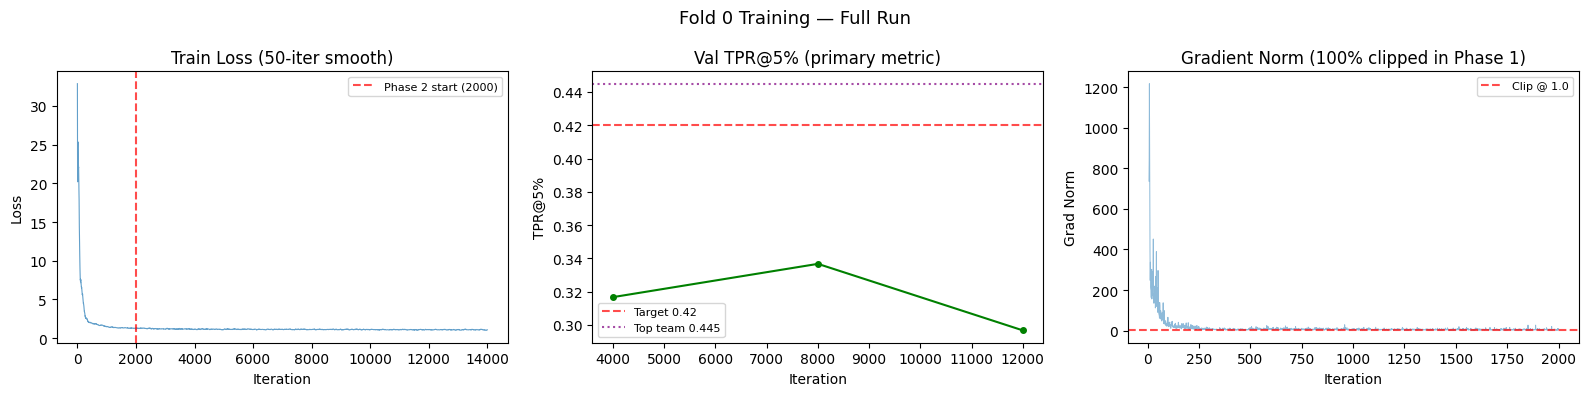

✓ Training curve saved: d:\IIT\L6\FYP\ChagaSight\checkpoints\fold0_training_curve.png

📁 Saved checkpoints:
  fold0_best.pt  (2084 MB)
  fold0_latest.pt  (2084 MB)

NEXT STEPS:
  1. Run folds 1-4 (change FOLD = 1, 2, 3, 4)
  2. Run evaluation_complete.ipynb for ensemble metrics
  3. If score < 0.35, run MAE + ST-MEM pretraining first


In [7]:
# ═══════════════════════════════════════════════════════════════
# Cell 7: Save Results + Plot Training Curve
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

results_df = pd.DataFrame([metrics])
results_df['fold'] = FOLD
results_df['quick_test'] = QUICK_TEST
results_csv = CHECKPOINT_DIR / f'fold{FOLD}_results.csv'
results_df.to_csv(results_csv, index=False)
print(f'✓ Results saved: {results_csv}')

history = trainer.history
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Fold {FOLD} Training — {"QUICK TEST" if QUICK_TEST else "Full Run"}', fontsize=13)

# Loss
if history['train_loss']:
    axes[0].plot(history['train_loss'], alpha=0.7, linewidth=0.8)
    axes[0].set_title('Train Loss (50-iter smooth)')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Loss')
    # Mark Phase 2 start
    p2_start = PHASE1_ITERATIONS
    if p2_start < len(history['train_loss']):
        axes[0].axvline(x=p2_start, color='r', linestyle='--', alpha=0.7, label=f'Phase 2 start ({p2_start})')
        axes[0].legend(fontsize=8)

# TPR@5%
if history['val_tpr_5pct']:
    val_iters = [trainer.val_every_n_iters * (i+1) for i in range(len(history['val_tpr_5pct']))]
    axes[1].plot(val_iters, history['val_tpr_5pct'], 'g-o', markersize=4)
    axes[1].set_title('Val TPR@5% (primary metric)')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('TPR@5%')
    if not QUICK_TEST:
        axes[1].axhline(y=0.42, color='r', linestyle='--', alpha=0.7, label='Target 0.42')
        axes[1].axhline(y=0.445, color='purple', linestyle=':', alpha=0.7, label='Top team 0.445')
        axes[1].legend(fontsize=8)

# Gradient norm
if history['grad_norm']:
    g = history['grad_norm']
    axes[2].plot(g[:min(2000, len(g))], alpha=0.5, linewidth=0.7)
    axes[2].set_title('Gradient Norm (Phase 1)')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Grad Norm')
    axes[2].axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Clip @ 1.0')
    axes[2].legend(fontsize=8)
    # Check for high clipping rate
    clipped = sum(1 for x in g[:2000] if x > 1.0)
    pct = 100 * clipped / max(1, len(g[:2000]))
    axes[2].set_title(f'Gradient Norm ({pct:.0f}% clipped in Phase 1)')

plt.tight_layout()
plot_path = CHECKPOINT_DIR / f'fold{FOLD}_training_curve.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Training curve saved: {plot_path}')

# Print saved checkpoints
print('\n📁 Saved checkpoints:')
for p in sorted(CHECKPOINT_DIR.glob(f'fold{FOLD}*.pt')):
    size_mb = p.stat().st_size / 1e6
    print(f'  {p.name}  ({size_mb:.0f} MB)')

print('\n' + '='*62)
print('NEXT STEPS:')
if QUICK_TEST:
    print('  1. Smoke-test passed? Set QUICK_TEST=False and run full training')
else:
    print('  1. Run folds 1-4 (change FOLD = 1, 2, 3, 4)')
    print('  2. Run evaluation_complete.ipynb for ensemble metrics')
    print('  3. If score < 0.35, run MAE + ST-MEM pretraining first')
print('='*62)